Balancing Dataset for Naive Bayes AQI Classification

Using stratified train-test splits and oversampling techniques


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)



First, load the original dataset and see what we're working with.

In [ ]:
df = pd.read_csv('cleaned_data.csv')

def to_bool_if_possible(series):
    mapping = {'True': True, 'False': False, '1': True, '0': False, 'true': True, 'false': False}
    mapped = series.astype(str).str.strip().map(mapping)
    if mapped.notna().all():
        return mapped.astype(bool)
    return series

for target_col in ['new_case', 'new_death']:
    if target_col in df.columns:
        df[target_col] = to_bool_if_possible(df[target_col])

print('Dataset shape:', df.shape)
print('\nColumn names and types:')
print(df.dtypes)


Dataset shape: (75585, 8)

Column names and types:
pm25         object
pm10         object
no2          object
so2          object
co           object
o3           object
new_case       bool
new_death      bool
dtype: object

First few rows:


,pm25,pm10,no2,so2,co,o3,new_case,new_death
0,IT3,IT4,Heavy,Heavy,Heavy,Moderate,False,False
1,IT3,IT3,Heavy,Heavy,Heavy,Moderate,False,False
2,IT2,IT3,Heavy,Heavy,Heavy,Moderate,True,False
3,IT2,IT3,Heavy,Heavy,Heavy,Moderate,False,False
4,IT2,IT2,Heavy,Heavy,Heavy,Moderate,False,False


 Analyze Class Imbalance

Check the distribution of our target variables to understand the imbalance problem.

In [16]:
def summarize_target(series, name):
    counts = series.value_counts(dropna=False)
    percentages = series.value_counts(normalize=True, dropna=False) * 100

    print('=' * 50)
    print(f'TARGET VARIABLE: {name}')
    print('=' * 50)
    print(counts)
    print('\nNormalized (%):')
    print(percentages)

    false_count = int(counts.get(False, 0))
    true_count = int(counts.get(True, 0))
    if true_count > 0:
        print(f'\nClass ratio (False:True) = {false_count / true_count:.1f}:1')
    else:
        print('\nClass ratio (False:True) = undefined (no True class present)')

summarize_target(df['new_case'], 'new_case')
print()
summarize_target(df['new_death'], 'new_death')

TARGET VARIABLE: new_case
new_case
False    60722
True     14863
Name: count, dtype: int64

Normalized (%):
new_case
False    80.336046
True     19.663954
Name: proportion, dtype: float64

Class ratio (False:True) = 4.1:1

TARGET VARIABLE: new_death
new_death
False    75023
True       562
Name: count, dtype: int64

Normalized (%):
new_death
False    99.256466
True      0.743534
Name: proportion, dtype: float64

Class ratio (False:True) = 133.5:1


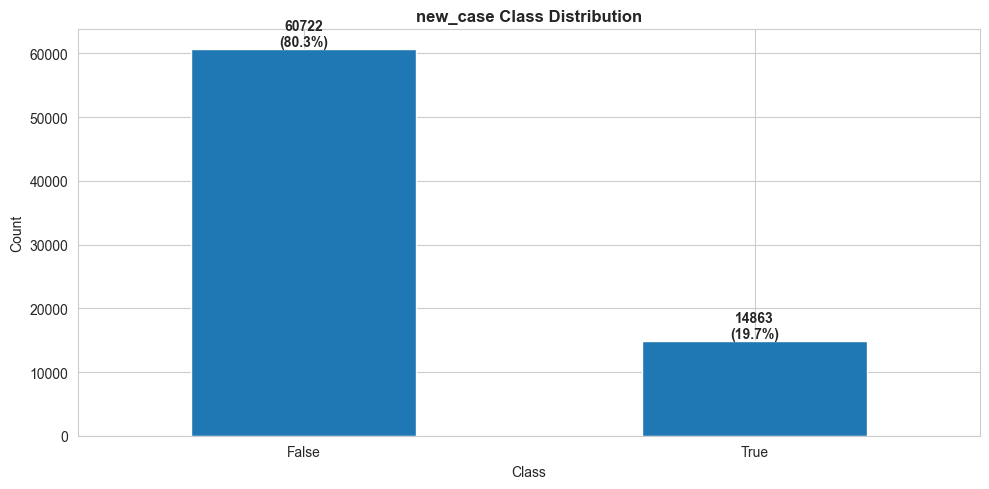

In [48]:
# visualize the class imbalance
new_case_counts = df['new_case'].value_counts(dropna=False)
labels = [str(v) for v in new_case_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))

new_case_counts.plot(kind='bar', ax=ax)
ax.set_title('new_case Class Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(labels, rotation=0)

for i, (label, count) in enumerate(zip(labels, new_case_counts.values)):
    percentage = (count / new_case_counts.sum()) * 100
    ax.text(i, count, f'{int(count)}\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


Stratified Train-Test Split
Use stratification so train and test keep the same class proportions.

If your dataset has only one class in `new_case`, stratified splitting cannot run. In that case, fix the upstream SQL/data join first, regenerate `cleaned_data.csv`, and rerun this notebook.

In [ ]:
# Ensure dependencies and df exist even if this cell is run out of order
if 'pd' not in globals():
    import pandas as pd
if 'train_test_split' not in globals():
    from sklearn.model_selection import train_test_split

if 'df' not in globals():
    df = pd.read_csv('cleaned_data.csv')

    def to_bool_if_possible(series):
        mapping = {'True': True, 'False': False, '1': True, '0': False, 'true': True, 'false': False}
        mapped = series.astype(str).str.strip().map(mapping)
        if mapped.notna().all():
            return mapped.astype(bool)
        return series

    for target_col in ['new_case', 'new_death']:
        if target_col in df.columns:
            df[target_col] = to_bool_if_possible(df[target_col])

# Drop new_death as it's too imbalanced for modeling in this workflow
X = df.drop(['new_case', 'new_death'], axis=1)
y = df['new_case']

class_counts = y.value_counts(dropna=False)
if y.nunique(dropna=False) < 2:
    raise ValueError(
        'Cannot split/oversample: `new_case` has only one class in cleaned_data.csv. '
        'Fix the SQL join/data extraction first, regenerate the CSV, then rerun.'
    )

# Perform stratified train-test split (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create DataFrames with target variable for easier manipulation
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

print('cleaned_dataset distribution:')
print(f'Total: {len(df)} rows')
print(f"False: {int(class_counts.get(False, 0))} ({(class_counts.get(False, 0) / len(y)) * 100:.1f}%)")
print(f"True:  {int(class_counts.get(True, 0))} ({(class_counts.get(True, 0) / len(y)) * 100:.1f}%)")

train_counts = y_train.value_counts(dropna=False)
test_counts = y_test.value_counts(dropna=False)

print('\nAfter stratified split:')
print(f'\nTrain set ({len(df_train)} rows):')
print(f"  False: {int(train_counts.get(False, 0))} ({(train_counts.get(False, 0) / len(y_train)) * 100:.1f}%)")
print(f"  True:  {int(train_counts.get(True, 0))} ({(train_counts.get(True, 0) / len(y_train)) * 100:.1f}%)")

print(f'\nTest set ({len(df_test)} rows) - kept at original distribution:')
print(f"  False: {int(test_counts.get(False, 0))} ({(test_counts.get(False, 0) / len(y_test)) * 100:.1f}%)")
print(f"  True:  {int(test_counts.get(True, 0))} ({(test_counts.get(True, 0) / len(y_test)) * 100:.1f}%)")

Original dataset distribution:
Total: 75585 rows
False: 60722 (80.3%)
True:  14863 (19.7%)

After stratified split:

Train set (60468 rows):
  False: 48578 (80.3%)
  True:  11890 (19.7%)

Test set (15117 rows) - kept at original distribution:
  False: 12144 (80.3%)
  True:  2973 (19.7%)


Balance Training Set Using Oversampling

Now comes the balancing step! We'll **oversample the minority class** (new_case = True) to match the majority class.

**What is oversampling?** We randomly duplicate rows from the minority class until it has the same number of samples as the majority class. This creates a 50-50 balanced training set.

**Why only in training?** We balance the training data to help the model learn both classes equally. We keep the test data imbalanced to get a realistic measure of performance on real-world data.

**Method**: Use `pandas.DataFrame.sample()` with `replace=True` to randomly duplicate minority class samples.

In [ ]:
# Separate majority and minority classes in training set
df_train_majority = df_train[df_train['new_case'] == False]
df_train_minority = df_train[df_train['new_case'] == True]

if len(df_train_minority) == 0:
    raise ValueError(
        'Cannot oversample: training split has zero True samples. '
        'Fix upstream data generation and rerun.'
    )

print('Training set before balancing:')
print(f'  Majority class (False): {len(df_train_majority)} samples')
print(f'  Minority class (True):  {len(df_train_minority)} samples')
print(f'  Ratio: {len(df_train_majority) / len(df_train_minority):.1f}:1')

# Random oversampling by duplication (simple and valid for categorical features)
df_train_minority_oversampled = df_train_minority.sample(
    n=len(df_train_majority),
    replace=True,
    random_state=42
)

#balanced classes
df_train_balanced = pd.concat([df_train_majority, df_train_minority_oversampled], ignore_index=True)

balanced_counts = df_train_balanced['new_case'].value_counts(dropna=False)
print('\nTraining set after balancing:')
print(f"  Majority class (False): {int(balanced_counts.get(False, 0))} samples")
print(f"  Minority class (True):  {int(balanced_counts.get(True, 0))} samples")
print(f"  Ratio: {balanced_counts.get(False, 0) / balanced_counts.get(True, 1):.1f}:1")
print(f'  Total: {len(df_train_balanced)} samples')
print(f'\nNote: Training set grew from {len(df_train)} to {len(df_train_balanced)} rows due to oversampling.')

Training set before balancing:
  Majority class (False): 48578 samples
  Minority class (True):  11890 samples
  Ratio: 4.1:1

Training set after balancing:
  Majority class (False): 48578 samples
  Minority class (True):  48578 samples
  Ratio: 1.0:1
  Total: 97156 samples

Note: Training set grew from 60468 to 97156 rows due to oversampling.


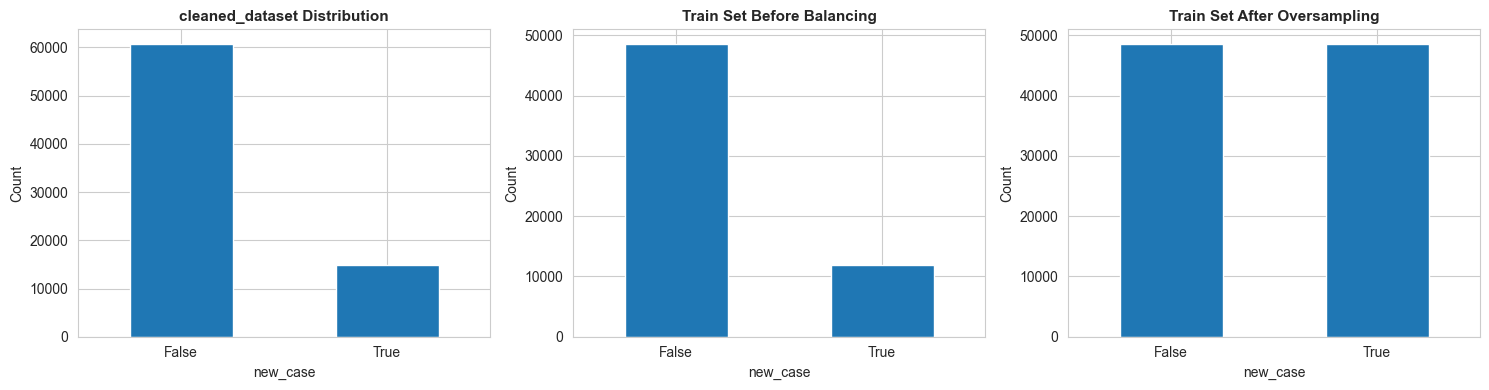

In [54]:
# Visualize the balancing effect
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

orig_counts = df['new_case'].value_counts(dropna=False)
train_counts = y_train.value_counts(dropna=False)
bal_counts = df_train_balanced['new_case'].value_counts(dropna=False)

#cleaned_dataset distribution
orig_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('cleaned_dataset Distribution', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels([str(v) for v in orig_counts.index], rotation=0)

# Before balancing (train set only)
train_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title('Train Set Before Balancing', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels([str(v) for v in train_counts.index], rotation=0)

# After balancing
bal_counts.plot(kind='bar', ax=axes[2])
axes[2].set_title('Train Set After Oversampling', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels([str(v) for v in bal_counts.index], rotation=0)

plt.tight_layout()
plt.show()

Save Balanced Datasets

In [ ]:
from pathlib import Path

# Save the balanced training set directly to 'train_balanced.csv' (no fallback)
train_out_path = Path('train_balanced.csv')
df_train_balanced.to_csv(train_out_path, index=False)
print(f'Saved: {train_out_path.name}')
print(f'  - Shape: {df_train_balanced.shape}')
balanced_counts = df_train_balanced['new_case'].value_counts(dropna=False)
print(
    f"  - Class distribution: "
    f"{balanced_counts.get(False, 0) / len(df_train_balanced) * 100:.1f}% False, "
    f"{balanced_counts.get(True, 0) / len(df_train_balanced) * 100:.1f}% True"
)

Saved: train_balanced.csv
  - Shape: (97156, 7)
  - Class distribution: 50.0% False, 50.0% True
